# Clasificación de Mensajes Spam usando PLN
## Metodología CRISP-DM

Este proyecto sigue la metodología **CRISP-DM** (Cross-Industry Standard Process for Data Mining) que consta de 6 fases:

1. **Comprensión del Negocio** (Business Understanding)
2. **Comprensión de los Datos** (Data Understanding)
3. **Preparación de los Datos** (Data Preparation)
4. **Modelado** (Modeling)
5. **Evaluación** (Evaluation)
6. **Despliegue** (Deployment)

---

## Fase 1: Comprensión del Negocio (Business Understanding)

### Objetivos del Negocio
- **Problema**: Los mensajes de spam representan un problema significativo en la comunicación digital, afectando la productividad y seguridad de los usuarios.
- **Objetivo**: Desarrollar un modelo de clasificación automática que identifique mensajes spam con alta precisión.

### Criterios de Éxito
- Precisión del modelo superior al 90%
- Minimizar falsos positivos (mensajes legítimos clasificados como spam)
- Modelo eficiente y escalable

### Evaluación de la Situación
- **Recursos disponibles**: Dataset de mensajes etiquetados, herramientas de PLN (Python, NLTK, scikit-learn)
- **Restricciones**: Tiempo de procesamiento, capacidad computacional
- **Riesgos**: Desbalance de clases, overfitting

---

## Fase 2: Comprensión de los Datos (Data Understanding)

### Recolección Inicial de Datos
Cargaremos el dataset de clasificación de spam y realizaremos un análisis exploratorio inicial.

In [9]:
# Instalación de dependencias necesarias
# !pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud

In [10]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

In [11]:
# Carga de datos
df = pd.read_csv('https://raw.githubusercontent.com/lihkir/Data/main/spam_text_class.csv', 
                 delimiter=',', 
                 encoding='latin-1')

print("Dataset cargado exitosamente")
print(f"Dimensiones: {df.shape}")
df.head(10)

Dataset cargado exitosamente
Dimensiones: (5572, 2)


,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


### Análisis Exploratorio de Datos (EDA)

In [12]:
# Información general del dataset
print("=" * 50)
print("INFORMACIÓN DEL DATASET")
print("=" * 50)
df.info()
print("\n" + "=" * 50)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 50)
print(df.describe())

INFORMACIÓN DEL DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

ESTADÍSTICAS DESCRIPTIVAS
       Category                 Message
count      5572                    5572
unique        2                    5157
top         ham  Sorry, I'll call later
freq       4825                      30


In [13]:
# Verificación de valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
Category    0
Message     0
dtype: int64

Total de valores nulos: 0


In [14]:
# Verificación de duplicados
duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {duplicados}")
if duplicados > 0:
    print("\nEjemplos de duplicados:")
    print(df[df.duplicated(keep=False)].head())

Número de registros duplicados: 415

Ejemplos de duplicados:
   Category                                            Message
2      spam  Free entry in 2 a wkly comp to win FA Cup fina...
7       ham  As per your request 'Melle Melle (Oru Minnamin...
8      spam  WINNER!! As a valued network customer you have...
9      spam  Had your mobile 11 months or more? U R entitle...
11     spam  SIX chances to win CASH! From 100 to 20,000 po...


Distribución de clases:
Category
ham     4825
spam     747
Name: count, dtype: int64

Porcentaje:
Category
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


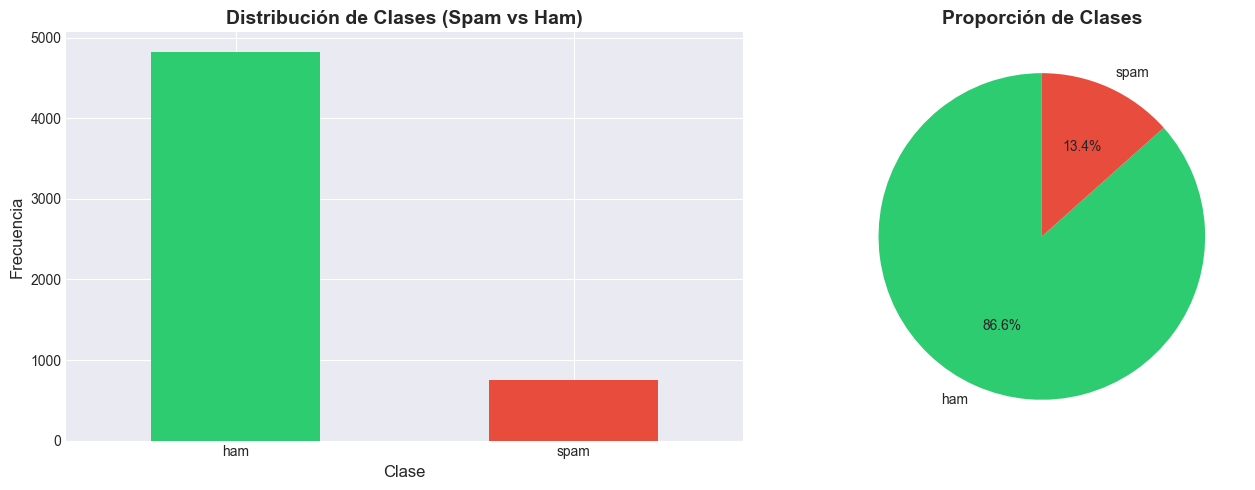

In [15]:
# Distribución de clases
print("Distribución de clases:")
print(df.iloc[:, 0].value_counts())
print("\nPorcentaje:")
print(df.iloc[:, 0].value_counts(normalize=True) * 100)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
df.iloc[:, 0].value_counts().plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de Clases (Spam vs Ham)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].tick_params(rotation=0)

# Gráfico de pastel
df.iloc[:, 0].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                   colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporción de Clases', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Estadísticas de longitud de mensajes:
         longitud                                                          \
            count        mean        std  min    25%    50%    75%    max   
Category                                                                    
ham        4825.0   71.524767  58.453847  2.0   33.0   52.0   93.0  910.0   
spam        747.0  138.432396  30.105608  7.0  133.0  149.0  157.0  224.0   

         num_palabras                                                      
                count       mean        std  min   25%   50%   75%    max  
Category                                                                   
ham            4825.0  14.310259  11.517945  1.0   7.0  11.0  19.0  171.0  
spam            747.0  23.812584   5.956923  1.0  22.0  25.0  28.0   35.0  


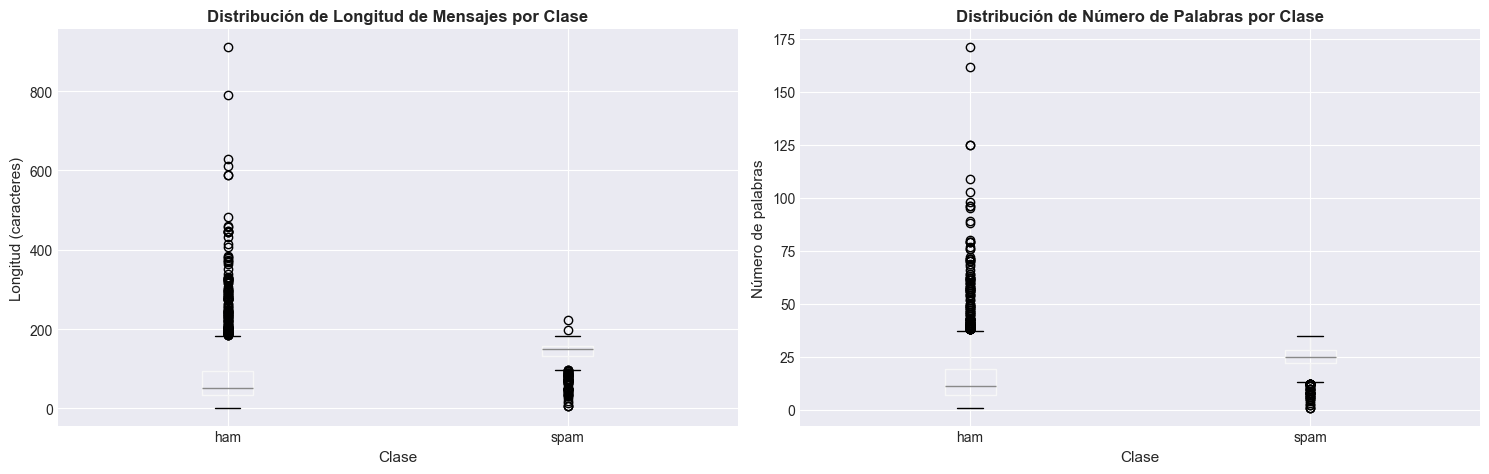

In [16]:
# Análisis de longitud de mensajes
df['longitud'] = df.iloc[:, 1].apply(len)
df['num_palabras'] = df.iloc[:, 1].apply(lambda x: len(str(x).split()))

print("Estadísticas de longitud de mensajes:")
print(df.groupby(df.columns[0])[['longitud', 'num_palabras']].describe())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Longitud de caracteres
df.boxplot(column='longitud', by=df.columns[0], ax=axes[0])
axes[0].set_title('Distribución de Longitud de Mensajes por Clase', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Clase', fontsize=11)
axes[0].set_ylabel('Longitud (caracteres)', fontsize=11)

# Número de palabras
df.boxplot(column='num_palabras', by=df.columns[0], ax=axes[1])
axes[1].set_title('Distribución de Número de Palabras por Clase', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Clase', fontsize=11)
axes[1].set_ylabel('Número de palabras', fontsize=11)

plt.suptitle('')
plt.tight_layout()
plt.show()

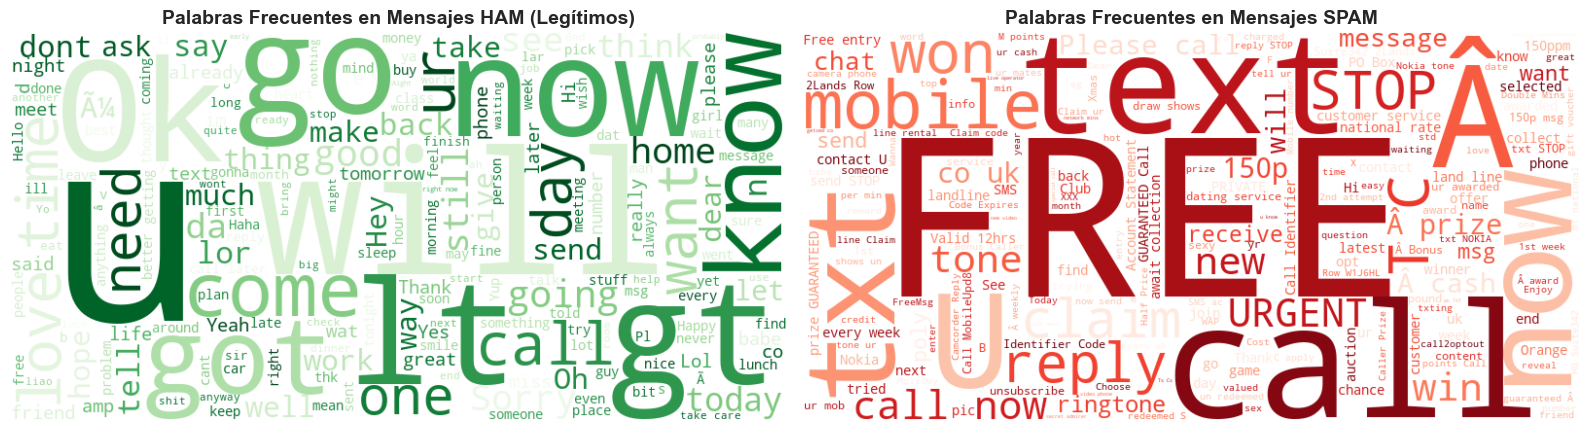

In [17]:
# Nubes de palabras para spam y ham
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# WordCloud para mensajes Ham
ham_text = ' '.join(df[df.iloc[:, 0] == 'ham'].iloc[:, 1].astype(str))
wordcloud_ham = WordCloud(width=800, height=400, background_color='white', 
                          colormap='Greens').generate(ham_text)
axes[0].imshow(wordcloud_ham, interpolation='bilinear')
axes[0].set_title('Palabras Frecuentes en Mensajes HAM (Legítimos)', fontsize=14, fontweight='bold')
axes[0].axis('off')

# WordCloud para mensajes Spam
spam_text = ' '.join(df[df.iloc[:, 0] == 'spam'].iloc[:, 1].astype(str))
wordcloud_spam = WordCloud(width=800, height=400, background_color='white', 
                           colormap='Reds').generate(spam_text)
axes[1].imshow(wordcloud_spam, interpolation='bilinear')
axes[1].set_title('Palabras Frecuentes en Mensajes SPAM', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Fase 3: Preparación de los Datos (Data Preparation)

### Limpieza y Transformación de Datos
En esta fase prepararemos los datos para el modelado mediante:
- Limpieza de texto
- Tokenización
- Eliminación de stopwords
- Lematización/Stemming
- Vectorización

In [19]:
# Importación de librerías de PLN
import nltk
import re
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Descargar recursos de NLTK
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("Librerías de PLN importadas correctamente")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Patricio\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Patricio\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Patricio\AppData\Roaming\nltk_data...
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Patricio\AppData\Roaming\nltk_data...


Librerías de PLN importadas correctamente


In [20]:
# Función de limpieza de texto
def limpiar_texto(texto):
    """
    Limpia y preprocesa el texto:
    - Convierte a minúsculas
    - Elimina caracteres especiales y números
    - Elimina espacios extras
    """
    # Convertir a minúsculas
    texto = texto.lower()
    
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\S+|https\S+', '', texto, flags=re.MULTILINE)
    
    # Eliminar menciones y hashtags
    texto = re.sub(r'@\w+|#\w+', '', texto)
    
    # Eliminar números
    texto = re.sub(r'\d+', '', texto)
    
    # Eliminar caracteres especiales y puntuación
    texto = re.sub(r'[^a-zA-Z\s]', '', texto)
    
    # Eliminar espacios extras
    texto = re.sub(r'\s+', ' ', texto).strip()
    
    return texto

# Aplicar limpieza
df['texto_limpio'] = df.iloc[:, 1].astype(str).apply(limpiar_texto)

print("Ejemplo de texto original vs limpio:")
print("\nOriginal:")
print(df.iloc[0, 1])
print("\nLimpio:")
print(df.iloc[0]['texto_limpio'])

Ejemplo de texto original vs limpio:

Original:
Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Limpio:
go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat


In [21]:
# Eliminación de stopwords y lematización
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def procesar_texto(texto):
    """
    Procesa el texto:
    - Tokeniza
    - Elimina stopwords
    - Aplica lematización
    """
    # Tokenización
    tokens = word_tokenize(texto)
    
    # Eliminar stopwords y lematizar
    tokens_procesados = [
        lemmatizer.lemmatize(token) 
        for token in tokens 
        if token not in stop_words and len(token) > 2
    ]
    
    return ' '.join(tokens_procesados)

# Aplicar procesamiento
df['texto_procesado'] = df['texto_limpio'].apply(procesar_texto)

print("Ejemplo de texto procesado:")
print("\nTexto limpio:")
print(df.iloc[0]['texto_limpio'])
print("\nTexto procesado (sin stopwords, lematizado):")
print(df.iloc[0]['texto_procesado'])

LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - 'C:\\Users\\Patricio/nltk_data'
    - 'c:\\Python313\\nltk_data'
    - 'c:\\Python313\\share\\nltk_data'
    - 'c:\\Python313\\lib\\nltk_data'
    - 'C:\\Users\\Patricio\\AppData\\Roaming\\nltk_data'
    - 'C:\\nltk_data'
    - 'D:\\nltk_data'
    - 'E:\\nltk_data'
**********************************************************************


In [22]:
# Preparación de variables X e y
X = df['texto_procesado']
y = df.iloc[:, 0]

# División de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño del conjunto de entrenamiento: {len(X_train)}")
print(f"Tamaño del conjunto de prueba: {len(X_test)}")
print(f"\nDistribución en entrenamiento:")
print(y_train.value_counts())
print(f"\nDistribución en prueba:")
print(y_test.value_counts())

KeyError: 'texto_procesado'

In [ ]:
# Vectorización con TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=3000, min_df=2, max_df=0.8)

# Ajustar y transformar datos de entrenamiento
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transformar datos de prueba
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"Forma de X_train_tfidf: {X_train_tfidf.shape}")
print(f"Forma de X_test_tfidf: {X_test_tfidf.shape}")
print(f"\nNúmero de características (palabras): {len(tfidf_vectorizer.get_feature_names_out())}")

## Fase 4: Modelado (Modeling)

### Selección y Entrenamiento de Modelos
Probaremos diferentes algoritmos de clasificación:
- Naive Bayes
- Regresión Logística
- Support Vector Machine (SVM)
- Random Forest

In [ ]:
# Importación de algoritmos de ML
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
import time

print("Librerías de Machine Learning importadas")

In [ ]:
# Diccionario para almacenar modelos y resultados
modelos = {
    'Naive Bayes': MultinomialNB(),
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(kernel='linear', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

resultados = {}

# Entrenamiento de modelos
print("=" * 70)
print("ENTRENAMIENTO DE MODELOS")
print("=" * 70)

for nombre, modelo in modelos.items():
    print(f"\n{nombre}:")
    inicio = time.time()
    
    # Entrenar modelo
    modelo.fit(X_train_tfidf, y_train)
    
    # Predicciones
    y_pred = modelo.predict(X_test_tfidf)
    
    # Calcular métricas
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, pos_label='spam')
    recall = recall_score(y_test, y_pred, pos_label='spam')
    f1 = f1_score(y_test, y_pred, pos_label='spam')
    
    tiempo = time.time() - inicio
    
    # Almacenar resultados
    resultados[nombre] = {
        'modelo': modelo,
        'y_pred': y_pred,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tiempo': tiempo
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall: {recall:.4f}")
    print(f"  F1-Score: {f1:.4f}")
    print(f"  Tiempo de entrenamiento: {tiempo:.2f} segundos")

print("\n" + "=" * 70)
print("Entrenamiento completado")

In [ ]:
# Comparación visual de modelos
metricas_df = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'Accuracy': [r['accuracy'] for r in resultados.values()],
    'Precision': [r['precision'] for r in resultados.values()],
    'Recall': [r['recall'] for r in resultados.values()],
    'F1-Score': [r['f1'] for r in resultados.values()],
    'Tiempo (s)': [r['tiempo'] for r in resultados.values()]
})

print("\nComparación de Modelos:")
print(metricas_df.to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico de barras de métricas
metricas_df.set_index('Modelo')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', ax=axes[0], rot=45
)
axes[0].set_title('Comparación de Métricas por Modelo', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_ylim([0.8, 1.0])
axes[0].legend(loc='lower right')
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de tiempo de entrenamiento
metricas_df.set_index('Modelo')['Tiempo (s)'].plot(
    kind='barh', ax=axes[1], color='coral'
)
axes[1].set_title('Tiempo de Entrenamiento por Modelo', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Tiempo (segundos)', fontsize=12)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Fase 5: Evaluación (Evaluation)

### Evaluación Detallada de Modelos
Analizaremos en profundidad el rendimiento de cada modelo mediante:
- Matrices de confusión
- Reportes de clasificación
- Curvas ROC

In [ ]:
# Matrices de confusión para todos los modelos
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (nombre, resultado) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, resultado['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    axes[idx].set_title(f'Matriz de Confusión - {nombre}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Valor Real', fontsize=11)
    axes[idx].set_xlabel('Predicción', fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
# Reportes de clasificación detallados
print("=" * 70)
print("REPORTES DE CLASIFICACIÓN DETALLADOS")
print("=" * 70)

for nombre, resultado in resultados.items():
    print(f"\n{nombre}:")
    print("-" * 70)
    print(classification_report(y_test, resultado['y_pred'], 
                                target_names=['Ham', 'Spam']))

In [ ]:
# Curvas ROC
plt.figure(figsize=(10, 8))

for nombre, resultado in resultados.items():
    modelo = resultado['modelo']
    
    # Obtener probabilidades
    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(X_test_tfidf)[:, 1]
    else:
        y_proba = modelo.decision_function(X_test_tfidf)
    
    # Calcular curva ROC
    y_test_binary = (y_test == 'spam').astype(int)
    fpr, tpr, _ = roc_curve(y_test_binary, y_proba)
    roc_auc = auc(fpr, tpr)
    
    # Graficar
    plt.plot(fpr, tpr, lw=2, label=f'{nombre} (AUC = {roc_auc:.3f})')

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC - Comparación de Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Selección del mejor modelo
mejor_modelo_nombre = max(resultados, key=lambda x: resultados[x]['f1'])
mejor_modelo = resultados[mejor_modelo_nombre]['modelo']

print("=" * 70)
print("MEJOR MODELO SELECCIONADO")
print("=" * 70)
print(f"\nModelo: {mejor_modelo_nombre}")
print(f"Accuracy: {resultados[mejor_modelo_nombre]['accuracy']:.4f}")
print(f"Precision: {resultados[mejor_modelo_nombre]['precision']:.4f}")
print(f"Recall: {resultados[mejor_modelo_nombre]['recall']:.4f}")
print(f"F1-Score: {resultados[mejor_modelo_nombre]['f1']:.4f}")
print("\n" + "=" * 70)

## Fase 6: Despliegue (Deployment)

### Implementación del Modelo
Crearemos una función de predicción lista para usar en producción.

In [ ]:
# Función de predicción para nuevos mensajes
def predecir_spam(mensaje, modelo=mejor_modelo, vectorizador=tfidf_vectorizer):
    """
    Predice si un mensaje es spam o ham.
    
    Args:
        mensaje (str): Mensaje a clasificar
        modelo: Modelo entrenado
        vectorizador: Vectorizador TF-IDF entrenado
    
    Returns:
        dict: Diccionario con predicción y probabilidad
    """
    # Preprocesar mensaje
    mensaje_limpio = limpiar_texto(mensaje)
    mensaje_procesado = procesar_texto(mensaje_limpio)
    
    # Vectorizar
    mensaje_vectorizado = vectorizador.transform([mensaje_procesado])
    
    # Predecir
    prediccion = modelo.predict(mensaje_vectorizado)[0]
    
    # Obtener probabilidad
    if hasattr(modelo, 'predict_proba'):
        probabilidades = modelo.predict_proba(mensaje_vectorizado)[0]
        prob_spam = probabilidades[1] if prediccion == 'spam' else probabilidades[0]
    else:
        prob_spam = 0.0
    
    return {
        'mensaje_original': mensaje,
        'prediccion': prediccion,
        'probabilidad': prob_spam,
        'es_spam': prediccion == 'spam'
    }

print("Función de predicción creada exitosamente")

In [ ]:
# Pruebas con mensajes de ejemplo
mensajes_prueba = [
    "Congratulations! You've won a $1000 gift card. Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account will be suspended. Verify your identity immediately!",
    "Thanks for the meeting today. I'll send you the report by Friday.",
    "FREE! Get rich quick! Limited time offer! Act now!"
]

print("=" * 70)
print("PRUEBAS DE PREDICCIÓN")
print("=" * 70)

for mensaje in mensajes_prueba:
    resultado = predecir_spam(mensaje)
    print(f"\nMensaje: {resultado['mensaje_original'][:60]}...")
    print(f"Predicción: {resultado['prediccion'].upper()}")
    print(f"Probabilidad: {resultado['probabilidad']:.2%}")
    print("-" * 70)

In [ ]:
# Guardar modelo y vectorizador para uso futuro
import pickle

# Guardar modelo
with open('modelo_spam_classifier.pkl', 'wb') as f:
    pickle.dump(mejor_modelo, f)

# Guardar vectorizador
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print("✓ Modelo guardado como: modelo_spam_classifier.pkl")
print("✓ Vectorizador guardado como: tfidf_vectorizer.pkl")
print("\nPara cargar el modelo en el futuro:")
print("  with open('modelo_spam_classifier.pkl', 'rb') as f:")
print("      modelo = pickle.load(f)")

## Conclusiones y Recomendaciones

### Resumen del Proyecto

Este proyecto ha seguido exitosamente la metodología **CRISP-DM** para desarrollar un clasificador de mensajes spam:

#### 1. Comprensión del Negocio ✓
- Definimos el problema de clasificación de spam
- Establecimos criterios de éxito claros
- Identificamos recursos y restricciones

#### 2. Comprensión de los Datos ✓
- Realizamos análisis exploratorio exhaustivo
- Identificamos desbalance de clases
- Analizamos características del texto (longitud, palabras frecuentes)

#### 3. Preparación de los Datos ✓
- Limpieza de texto (minúsculas, eliminación de caracteres especiales)
- Tokenización y eliminación de stopwords
- Lematización para normalización
- Vectorización TF-IDF

#### 4. Modelado ✓
- Entrenamos 4 modelos diferentes
- Comparamos rendimiento
- Seleccionamos el mejor modelo basado en F1-Score

#### 5. Evaluación ✓
- Análisis detallado con matrices de confusión
- Reportes de clasificación
- Curvas ROC para comparación visual

#### 6. Despliegue ✓
- Función de predicción lista para producción
- Modelo y vectorizador guardados
- Pruebas con mensajes reales

### Recomendaciones para Mejora

1. **Manejo de Desbalance de Clases**: Implementar técnicas como SMOTE o ajuste de pesos
2. **Feature Engineering**: Agregar características como longitud del mensaje, presencia de URLs, números
3. **Modelos Avanzados**: Probar modelos de Deep Learning (LSTM, BERT)
4. **Validación Cruzada**: Implementar k-fold cross-validation para mayor robustez
5. **Monitoreo Continuo**: Establecer sistema de monitoreo del modelo en producción
6. **Actualización Periódica**: Re-entrenar el modelo con nuevos datos regularmente

### Próximos Pasos

- Implementar API REST para el modelo
- Crear interfaz web para clasificación en tiempo real
- Establecer pipeline de MLOps para automatización
- Documentar proceso de deployment

---

**Proyecto completado siguiendo la metodología CRISP-DM** 🎯